In [20]:
import pandas as pd
import numpy as np
import re

### Reading file and printing relevant information

In [21]:
file = 'data125.txt'

In [22]:
with open(file) as f:
    text = f.readlines()
print(len(text))
print(type(text))
print(text[:2])

49331
<class 'list'>
['"Original reporting and analysis you won\'t find anywhere else. Original reporting and analysis you won\'t find anywhere else. Join today for original reporting and analysis you won\'t find anywhere else. Menswear - Spring 2020 Virgil Abloh’s latest proposition was a whiff of fresh air, showing that the idea of streetwear-as-fashion can indeed evolve into something new. Menswear - Spring 2020 Virgil Abloh’s latest proposition was a whiff of fresh air, showing that the idea of streetwear-as-fashion can indeed evolve into something new. PARIS, France — Is Virgil Abloh’s Off-White a lucrative schtick or cultural phenomenon? An exhibition of Abloh’s work, currently running at the Museum of Contemporary Art Chicago, manages to position him as a societal force. Shopping, the thing he propels his fans to go do, is now an experience just like music, film or art. No one understands that better than Abloh, who designed a new version of his Off-White x Nike Air Force 1 snea

### Removing copyright symbols

In [23]:
copyright = "©"
copyClean = []
for i in text:
    text2 = re.sub(copyright,"",i)
    copyClean.append(text2)

### Copyright symbols removed

In [24]:
print(len(copyClean))

49331


### Converting every token to lowercase

In [25]:
dataLower = map(lambda x:x.lower(),copyClean)

In [26]:
lowerCase = []
for i in dataLower:
    lowerCase.append(i)

In [27]:
print(len(lowerCase))
print(lowerCase[1][:100])
print(type(lowerCase))

49331
"

<class 'list'>


In [28]:
lowerCase

['"original reporting and analysis you won\'t find anywhere else. original reporting and analysis you won\'t find anywhere else. join today for original reporting and analysis you won\'t find anywhere else. menswear - spring 2020 virgil abloh’s latest proposition was a whiff of fresh air, showing that the idea of streetwear-as-fashion can indeed evolve into something new. menswear - spring 2020 virgil abloh’s latest proposition was a whiff of fresh air, showing that the idea of streetwear-as-fashion can indeed evolve into something new. paris, france — is virgil abloh’s off-white a lucrative schtick or cultural phenomenon? an exhibition of abloh’s work, currently running at the museum of contemporary art chicago, manages to position him as a societal force. shopping, the thing he propels his fans to go do, is now an experience just like music, film or art. no one understands that better than abloh, who designed a new version of his off-white x nike air force 1 sneakers for the exhibiti

### Removing special characters

In [29]:
specialCharRem = []
for i in lowerCase:
    specialChar = re.sub(r"[^a-zA-Z0-9.]+", ' ', i)
    specialCharRem.append(specialChar)
    


In [30]:
print(len(specialCharRem))

49331


In [31]:
print(specialCharRem[0][:])

 original reporting and analysis you won t find anywhere else. original reporting and analysis you won t find anywhere else. join today for original reporting and analysis you won t find anywhere else. menswear spring 2020 virgil abloh s latest proposition was a whiff of fresh air showing that the idea of streetwear as fashion can indeed evolve into something new. menswear spring 2020 virgil abloh s latest proposition was a whiff of fresh air showing that the idea of streetwear as fashion can indeed evolve into something new. paris france is virgil abloh s off white a lucrative schtick or cultural phenomenon an exhibition of abloh s work currently running at the museum of contemporary art chicago manages to position him as a societal force. shopping the thing he propels his fans to go do is now an experience just like music film or art. no one understands that better than abloh who designed a new version of his off white x nike air force 1 sneakers for the exhibition. along with mercha

### Handling digits

In [ ]:
import nltk
#nltk.download("all")
tokenList = []
for i in specialCharRem:
    tokens = nltk.tokenize.word_tokenize(i)
    tokenList.append(tokens)
    
print(len(tokenList))

In [ ]:
import inflect
p = inflect.engine()
x = p.number_to_words(123)
newTokens = []
for i in tokenList:
    for j in i:
        try:
            x = int(j)
            newTokens.append(x)
        except ValueError:
            newTokens.append(j)
        

In [ ]:
print(len(newTokens))
print(type(newTokens))
#print(newTokens)

### Converting digits to words

In [ ]:
import inflect
p = inflect.engine()

In [ ]:
for n, i in enumerate(newTokens):
    if type(i) == int:
        newTokens[n] = p.number_to_words(i)
    


In [ ]:
print(newTokens[:1000])

In [ ]:
data = ' '.join(newTokens)

In [ ]:
data

In [32]:
import pandas as pd
import numpy as np
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot


['original', 'reporting', 'and', 'analysis', 'you', 'won', 't', 'find', 'anywhere', 'else.', 'join', 'today', 'for', 'menswear', 'spring', '2020', 'virgil', 'abloh', 's', 'latest', 'proposition', 'was', 'a', 'whiff', 'of', 'fresh', 'air', 'showing', 'that', 'the', 'idea', 'streetwear', 'as', 'fashion', 'can', 'indeed', 'evolve', 'into', 'something', 'new.', 'paris', 'france', 'is', 'off', 'white', 'lucrative', 'schtick', 'or', 'cultural', 'phenomenon', 'an', 'exhibition', 'work', 'currently', 'running', 'at', 'museum', 'contemporary', 'art', 'chicago', 'manages', 'to', 'position', 'him', 'societal', 'force.', 'shopping', 'thing', 'he', 'propels', 'his', 'fans', 'go', 'do', 'now', 'experience', 'just', 'like', 'music', 'film', 'art.', 'no', 'one', 'understands', 'better', 'than', 'who', 'designed', 'new', 'version', 'x', 'nike', 'force', '1', 'sneakers', 'exhibition.', 'along', 'with', 'merchandise', 'sold', 'louis', 'vuitton', 'where', 'creative', 'director', 'both', 'opened', 'related

/home/akshat/.local/lib/python3.6/site-packages/ipykernel_launcher.py:15: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  from ipykernel import kernelapp as app


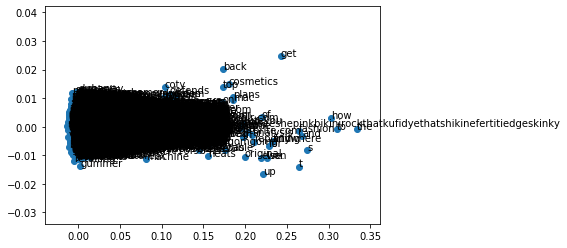

In [34]:
data = ' '.join(specialCharRem)

data_new = data.split()

sentences = data_new

model = Word2Vec([sentences], min_count=1)

words = list(model.wv.vocab)
print(words)
# print(model['humans'])

model.save('model.bin')

X = model[model.wv.vocab]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

pyplot.scatter(result[:, 0], result[:, 1])
words = list(model.wv.vocab)
for i, word in enumerate(words):
	pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

model.wv.save_word2vec_format('model.bin')
model.wv.save_word2vec_format('model.txt', binary=False)